In [1]:
import pandas as pd

df=pd.read_csv("Daily_Water_Intake.csv")
df

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor
...,...,...,...,...,...,...,...
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good


In [2]:
df.shape

(30000, 7)

In [3]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)',
       'Physical Activity Level', 'Weather', 'Hydration Level'],
      dtype='object')

In [4]:
df.dtypes

Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [6]:
df.describe()

,Age,Weight (kg),Daily Water Intake (liters)
count,30000.000000,30000.00000,30000.000000
mean,43.467667,76.84860,2.852444
std,14.998940,18.74494,0.835537
min,18.000000,45.00000,1.500000
25%,30.000000,61.00000,2.220000
50%,43.000000,77.00000,2.830000
75%,56.000000,93.00000,3.440000
max,69.000000,109.00000,5.430000


In [7]:
df["Gender"].value_counts()

Gender
Male      15032
Female    14968
Name: count, dtype: int64

In [8]:
df["Physical Activity Level"].value_counts()

Physical Activity Level
High        10069
Low         10011
Moderate     9920
Name: count, dtype: int64

In [9]:
df["Weather"].value_counts()

Weather
Hot       10081
Cold      10012
Normal     9907
Name: count, dtype: int64

In [10]:
df["Hydration Level"].value_counts()

Hydration Level
Good    23915
Poor     6085
Name: count, dtype: int64

In [11]:
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [12]:
df.tail()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good
29999,26,Female,98,4.43,Moderate,Hot,Good


In [13]:
df.sample(5)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
16072,50,Male,48,2.82,High,Normal,Good
23268,28,Male,96,3.73,Low,Hot,Good
2155,43,Female,92,3.57,Moderate,Hot,Good
15193,21,Male,102,4.17,High,Normal,Good
20715,69,Male,69,3.04,High,Hot,Good


In [14]:
df.isna().sum()

Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(338)

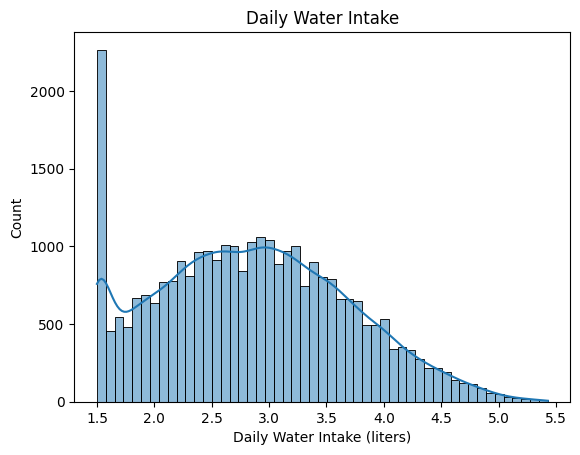

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Daily Water Intake (liters)"], kde=True)
plt.title("Daily Water Intake")
plt.show()

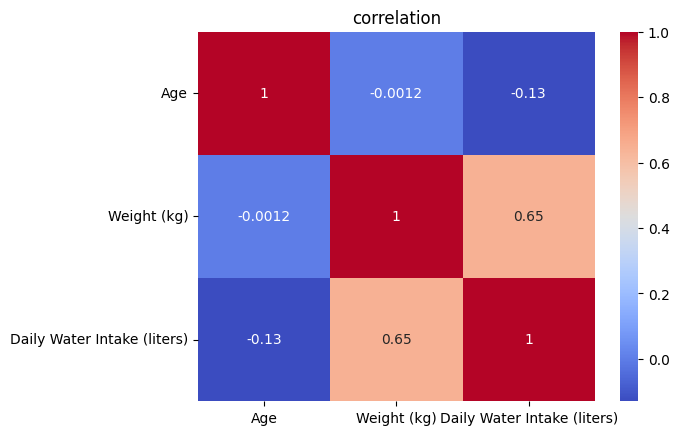

In [17]:
num_features=df[["Age", "Weight (kg)", "Daily Water Intake (liters)"]]
corr=num_features.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("correlation")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", 
        "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_columns    = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns    = ["Physical Activity Level"]
activity_order     = ["Low", "Moderate", "High"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe",    OneHotEncoder(),  categorical_columns),
        ("oe",     OrdinalEncoder(categories=[activity_order]), ordinal_columns)
    ]
)

# model Logistic Regression

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred_lr))
print("Classification Report :\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_lr))

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
print("\nCV Scores     :", scores)
print("CV Mean       : {:.4f}".format(scores.mean()))
print("CV Std        : {:.4f}".format(scores.std()))

Accuracy Score :  0.9966666666666667
Classification Report :
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4783
        Poor       1.00      0.98      0.99      1217

    accuracy                           1.00      6000
   macro avg       1.00      0.99      0.99      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix :
 [[4782    1]
 [  19 1198]]

CV Scores     : [0.99729167 0.99625    0.99729167 0.99708333 0.99520833]
CV Mean       : 0.9966
CV Std        : 0.0008


In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", 
        "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_columns    = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns    = ["Physical Activity Level"]
activity_order     = ["Low", "Moderate", "High"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe",    OneHotEncoder(),  categorical_columns),
        ("oe",     OrdinalEncoder(categories=[activity_order]), ordinal_columns)
    ]
)

model_forest = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred_rf))
print("Classification Report :\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_rf))

scores = cross_val_score(model_forest, X_train, y_train, cv=5, scoring="accuracy")
print("\nCV Scores     :", scores)
print("CV Mean       : {:.4f}".format(scores.mean()))
print("CV Std        : {:.4f}".format(scores.std()))

Accuracy Score :  0.9891666666666666
Classification Report :
               precision    recall  f1-score   support

        Good       0.99      1.00      0.99      4783
        Poor       0.98      0.96      0.97      1217

    accuracy                           0.99      6000
   macro avg       0.99      0.98      0.98      6000
weighted avg       0.99      0.99      0.99      6000

Confusion Matrix :
 [[4764   19]
 [  46 1171]]

CV Scores     : [0.98729167 0.9875     0.98979167 0.989375   0.98458333]
CV Mean       : 0.9877
CV Std        : 0.0018


In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", 
        "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_columns    = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns    = ["Physical Activity Level"]
activity_order     = ["Low", "Moderate", "High"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe",    OneHotEncoder(),  categorical_columns),
        ("oe",     OrdinalEncoder(categories=[activity_order]), ordinal_columns)
    ]
)

model_tree = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

model_tree.fit(X_train, y_train)
y_pred_dt = model_tree.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred_dt))
print("Classification Report :\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_dt))

scores = cross_val_score(model_tree, X_train, y_train, cv=5, scoring="accuracy")
print("\nCV Scores     :", scores)
print("CV Mean       : {:.4f}".format(scores.mean()))
print("CV Std        : {:.4f}".format(scores.std()))

Accuracy Score :  0.9975
Classification Report :
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4783
        Poor       0.99      1.00      0.99      1217

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix :
 [[4774    9]
 [   6 1211]]

CV Scores     : [0.99145833 0.99854167 0.99791667 0.99166667 0.99104167]
CV Mean       : 0.9941
CV Std        : 0.0034


In [21]:
data_baru = pd.DataFrame(
    [[38, "Female", 77, 1.00, "High", "Hot"]],
    columns=["Age","Gender","Weight (kg)","Daily Water Intake (liters)","Physical Activity Level","Weather"]
)

prediksi = model.predict(data_baru)[0]
print(f"model memprediksi tingkat hidrasi {prediksi}")

model memprediksi tingkat hidrasi Poor


In [23]:
import joblib

joblib.dump(model_tree,   "decision_tree_model.joblib")

['decision_tree_model.joblib']